In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

animal_ids = st.animal_labels(datapaths)

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
maps = ['19']

correlations_between = np.zeros(len(datapaths))
correlations_within = np.zeros(len(datapaths))
correlations_shuff = np.zeros(len(datapaths))
correlations_days = np.zeros(len(datapaths))


for i,datapath in enumerate(datapaths):
    hist_sorts1 = analysis.sort_maps_from_reference_AK(datapath, 'Context1', reference='17', maps = maps, transients = False, hist='hist', remove_inactive=False)
    hist_sorts2 = analysis.sort_maps_from_reference_AK(datapath, 'Context2', reference='17', maps = maps, transients = False, hist='hist', remove_inactive=False)
    correlations_between[i] = pop.ManifoldAnalysis.population_correlation(hist_sorts1[-1], hist_sorts2[-1])
    correlations_days[i] = pop.ManifoldAnalysis.population_correlation(hist_sorts1[0], hist_sorts1[-1])

    hist_shuff=analysis.sort_maps_from_reference_AK_shuffle(datapath, 'Context1', reference='17', maps = maps, transients = False, hist='hist',shuffle_type=None, remove_inactive=False)
    correlations_shuff[i] = pop.ManifoldAnalysis.population_correlation(hist_sorts1[-1], hist_shuff[-1])
    
    w1,w2 =analysis.sort_maps_from_reference_within_session_AK(datapath, 'Context1', maps=['19'])
    correlations_within[i] = pop.ManifoldAnalysis.population_correlation(w1[0], w2[0])


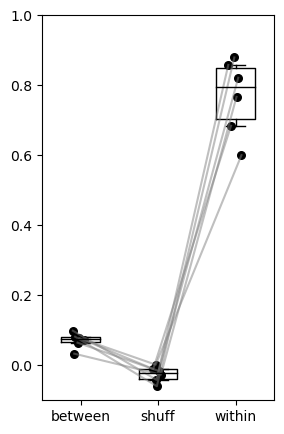

condition,between,shuff,within
animal,,,
170,0.0776,-0.0106,0.6843
51004,0.0731,0.0018,0.6003
51007,0.0987,-0.0415,0.8581
63,0.0646,-0.0161,0.8216
64,0.0816,-0.0598,0.8794
65,0.0332,-0.0267,0.7668


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,2.250996,2,1.125498,233.864153,4.018788e-09,0.9726,0.538497
1,Error,0.048126,10,0.004813,NaN,NaN,NaN,NaN


condition,between,shuff,within
animal,,,
170,0.0776,-0.0106,0.6843
51004,0.0731,0.0018,0.6003
51007,0.0987,-0.0415,0.8581
63,0.0646,-0.0161,0.8216
64,0.0816,-0.0598,0.8794
65,0.0332,-0.0267,0.7668


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,between,shuff,t-test,6.7368,0.0011,0.0033,**,2.7503,Cohen's d,0.0970,0.0353,True,0.1386
1,between,within,t-test,-16.1331,1.6673e-05,5.0018e-05,***,-6.5863,Cohen's d,-0.6970,0.1058,True,0.1761
2,shuff,within,t-test,-15.1699,2.2562e-05,6.7686e-05,***,-6.1931,Cohen's d,-0.7939,0.1282,True,0.7947


In [3]:
print_large('\n' + '='*50)
print_large('Population vector correlation between context, within context and shuffeled')
print_large('='*50)

conditions = ['between', 'shuff', 'within']

fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.array([correlations_between, correlations_shuff, correlations_within]).T, conditions,ax, '',ylim=[-0.1,1])
plt.show()  
print_large('RM ANOVA: between context, within context, shuffeled')
display(st.repeated_measures_anova_single_condition(
    np.array([correlations_between, correlations_shuff, correlations_within]).T,
    row_labels=animal_ids, col_labels=conditions, col_name='condition',
    title='Population vector correlation on d19: between / shuffled / within context'))
print_large('Post hoc: ')
display(st.post_hoc_timepoints(
    np.array([correlations_between, correlations_shuff, correlations_within]),
    row_labels=animal_ids, col_labels=conditions, col_name='condition',
    title='Post hoc: between / shuffled / within context (d19)'))

In [4]:
datapaths = [f'{DATA_ROOT}/170.h5', f'{DATA_ROOT}/51004.h5', f'{DATA_ROOT}/51007.h5', f'{DATA_ROOT}/63.h5', f'{DATA_ROOT}/64.h5', f'{DATA_ROOT}/65.h5']

results = []
results_shuff = []

for datapath in datapaths:
    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position_between(datapath, '19', 
        'Context1', '19', 'Context2', model='gnb', shuffle=False)
    results.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

    scores_test, scores_new_list, predictions_test, predictions_new_list, y_test, y_new_list = analysis.decode_position_between(datapath, '19', 
        'Context1', '19', 'Context2', model='gnb', shuffle=True)
    
    results_shuff.append({
        'datapath': datapath,
        'scores_test': scores_test,
        'scores_new_list': scores_new_list,
        'predictions_test': predictions_test,
        'predictions_new_list': predictions_new_list,
        'y_test': y_test,
        'y_new_list': y_new_list
    })

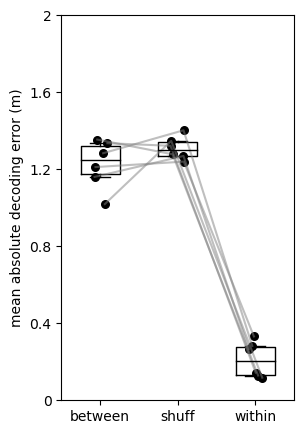

condition,between,shuff,within
animal,,,
170,1.1603,1.2690,0.2665
51004,1.2115,1.2397,0.3316
51007,1.0192,1.3472,0.1175
63,1.3353,1.3220,0.1437
64,1.3545,1.2778,0.1286
65,1.2835,1.4026,0.2824


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,4.487972,2,2.243986,229.386673,4.417590e-09,0.969837,0.920947
1,Error,0.097825,10,0.009783,NaN,NaN,NaN,NaN


condition,between,shuff,within
animal,,,
170,1.1603,1.2690,0.2665
51004,1.2115,1.2397,0.3316
51007,1.0192,1.3472,0.1175
63,1.3353,1.3220,0.1437
64,1.3545,1.2778,0.1286
65,1.2835,1.4026,0.2824


,Timepoint 1,Timepoint 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Diff,SD Diff,Normal Dist.,Normality p-value
0,between,shuff,t-test,-1.4281,0.2126,0.6379,,-0.5830,Cohen's d,-0.0823,0.1412,True,0.5745
1,between,within,t-test,15.9505,1.7632e-05,5.2897e-05,***,6.5118,Cohen's d,1.0157,0.1560,True,0.0799
2,shuff,within,t-test,22.3965,3.2974e-06,9.8923e-06,***,9.1433,Cohen's d,1.0980,0.1201,True,0.5666


In [5]:
print_large('\n' + '='*50)
print_large('decoding (MAE) between context, within context and shuffeled')
print_large('='*50)

mae_between = [res['scores_new_list'][0]['mae'] / 5 for res in results]
mae_shuff = [res['scores_new_list'][0]['mae'] / 5 for res in results_shuff]
mae_within = [res['scores_test']['mae'] / 5 for res in results]

conditions = ['between', 'shuff', 'within']
animal_ids = st.animal_labels([res['datapath'] for res in results])

fig, ax = plt.subplots(figsize=(3, 5))
plots.boxplot_with_points_and_lines(np.array([mae_between, mae_shuff, mae_within]).T, conditions,ax, '',ylim=[0,2])
ax.set_yticks([0, 0.4, 0.8, 1.2, 1.6, 2])
ax.set_yticklabels(['0', '0.4', '0.8', '1.2', '1.6', '2'])
ax.set_ylabel('mean absolute decoding error (m)')

plt.show()  
print_large('RM ANOVA: between context, within context, shuffeled')
display(st.repeated_measures_anova_single_condition(
    np.array([mae_between, mae_shuff, mae_within]).T,
    row_labels=animal_ids, col_labels=conditions, col_name='condition',
    title='Decoder MAE (m) on d19: between / shuffled / within context'))
print_large('Post hoc: ')
display(st.post_hoc_timepoints(
    np.array([mae_between, mae_shuff, mae_within]),
    row_labels=animal_ids, col_labels=conditions, col_name='condition',
    title='Post hoc: decoder MAE (m), between / shuffled / within context (d19)'))